# DenseR: Hidden State Divergence Validation

This notebook validates DenseR's core assumption: **cosine similarity in hidden-state space tracks semantic similarity in reasoning, and divergence points in hidden space correspond to actual reasoning divergence points.**

We run two experiments on a synthetic dataset of math completions:

| Experiment | Question | Method |
|---|---|---|
| **Exp 1** | Can hidden states localize *where* a reasoning error occurred? | Compare A (correct) vs B (same approach, arithmetic slip) — does the similarity drop at the known error token? |
| **Exp 2** | Does divergence magnitude track semantic distance? | Compare all pair types (A↔A_para, A↔B, A↔C, A↔D, B↔D) — is AUC ordered as expected? |

**Runtime:** ~5 min on T4 GPU with Qwen3-0.6B, 25 problems.

## 0 · Setup

In [1]:
!pip install -q transformers accelerate scipy matplotlib seaborn tqdm

In [2]:
import json, os
from collections import defaultdict
from typing import Dict, List, Tuple, Optional

import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import pearsonr, spearmanr
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=1.1)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


## 1 · Upload dataset

Upload `denser_divergence_test_data.json` using the file browser on the left, or run the cell below to upload interactively.

In [3]:
DATA_PATH = "denser_divergence_test_data.json"

if not os.path.exists(DATA_PATH):
    from google.colab import files
    uploaded = files.upload()  # upload the JSON here
    DATA_PATH = list(uploaded.keys())[0]

with open(DATA_PATH) as f:
    dataset = json.load(f)
problems = dataset["problems"]
print(f"Loaded {len(problems)} problems")

Saving denser_divergence_test_data.json to denser_divergence_test_data.json
Loaded 25 problems


## 2 · Load model

In [4]:
MODEL_NAME = "Qwen/Qwen3-0.6B"
WINDOW_SIZE = 5
OUTPUT_DIR = "denser_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"Loading {MODEL_NAME} …")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map=DEVICE if DEVICE == "cuda" else None,
    trust_remote_code=True,
)
if DEVICE == "cpu":
    model = model.to(DEVICE)
model.eval()

NUM_LAYERS = model.config.num_hidden_layers
LAST_LAYER = NUM_LAYERS       # index into output_hidden_states (0 = embeddings)
MID_LAYER  = NUM_LAYERS // 2
EARLY_LAYER = NUM_LAYERS // 4
LAYER_INDICES = sorted({LAST_LAYER, MID_LAYER, EARLY_LAYER})

print(f"  num_hidden_layers = {NUM_LAYERS}")
print(f"  extracting layers: last={LAST_LAYER}, mid={MID_LAYER}, early={EARLY_LAYER}")

Loading Qwen/Qwen3-0.6B …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

  num_hidden_layers = 28
  extracting layers: last=28, mid=14, early=7


## 3 · Extract hidden states for all completions

In [5]:
def extract_hidden_states(prompt, completion_text, layer_indices):
    """Returns (tokens_decoded, {layer_idx: (T_comp, D) tensor})."""
    prompt_ids = tokenizer.encode(prompt, add_special_tokens=True)
    full_ids   = tokenizer.encode(prompt + completion_text, add_special_tokens=True)
    prompt_len = len(prompt_ids)

    input_ids = torch.tensor([full_ids], device=DEVICE)
    with torch.no_grad():
        out = model(input_ids, output_hidden_states=True)

    states = {}
    for li in layer_indices:
        h = out.hidden_states[li][0, prompt_len:].cpu().float()
        states[li] = h

    tokens = [tokenizer.decode([t]) for t in full_ids[prompt_len:]]
    return tokens, states

In [6]:
# Encode every completion
encoded = {}   # {pid: {comp_type: {"tokens": [...], "states": {layer: Tensor}}}}

for prob in tqdm(problems, desc="Encoding"):
    pid = prob["id"]
    prompt = f"Solve the following problem:\n{prob['problem']}\n"
    encoded[pid] = {}
    for ctype, cdata in prob["completions"].items():
        try:
            tokens, states = extract_hidden_states(
                prompt, cdata["text"], LAYER_INDICES)
            encoded[pid][ctype] = {"tokens": tokens, "states": states}
        except Exception as e:
            print(f"  ⚠ {pid}/{ctype}: {e}")

# Free GPU
del model
if DEVICE == "cuda":
    torch.cuda.empty_cache()
print(f"\nEncoded {sum(len(v) for v in encoded.values())} completions across {len(encoded)} problems.")

Encoding:   0%|          | 0/25 [00:00<?, ?it/s]


Encoded 125 completions across 25 problems.


## 4 · Core utilities

In [7]:
def windowed_cosine_similarity(h1, h2, ws=WINDOW_SIZE):
    """
    For each token in h1, find max cosine-sim in h2 within a
    proportionally-aligned window of ±ws.  Returns (T1,) ndarray.
    """
    T1, D = h1.shape
    T2 = h2.shape[0]
    h1n = F.normalize(h1, dim=-1)
    h2n = F.normalize(h2, dim=-1)

    sims = np.zeros(T1)
    for t in range(T1):
        center = int(t * T2 / T1)
        lo = max(0, center - ws)
        hi = min(T2, center + ws + 1)
        cos = (h1n[t] @ h2n[lo:hi].T).cpu().numpy()
        sims[t] = cos.max()
    return sims


def detect_divergence_point(profile, kernel=3):
    """Steepest-drop index."""
    if len(profile) <= kernel:
        return 0
    sm = np.convolve(profile, np.ones(kernel)/kernel, mode="valid")
    return int(np.argmax(-np.diff(sm))) + kernel // 2


def true_divergence_index(comp_b_meta):
    """Token index where B's shared prefix with A ends."""
    prefix = comp_b_meta.get("shared_prefix_with_A")
    if prefix is None:
        return None
    return len(tokenizer.encode(prefix, add_special_tokens=False))

---
## 5 · Experiment 1 — Divergence-Point Recovery (A vs B)

 ws  │  n_all    r_all    ρ_all  MAE_all  │  n_flt    r_flt    ρ_flt  MAE_flt  │  mean sim@true
────────────────────────────────────────────────────────────────────────────────────────────────────
  0  │     25    0.655    0.502     20.9  │     15    0.832    0.790      5.2  │          0.787
  1  │     25    0.444    0.420     21.0  │     17    0.616    0.635      7.8  │          0.856
  2  │     25    0.392    0.522     14.4  │     19    0.556    0.681      9.4  │          0.907
  3  │     25    0.291    0.361     15.4  │     21    0.585    0.581     10.6  │          0.909
  5  │     25   -0.024    0.213     17.5  │     21    0.590    0.486     10.7  │          0.941

★ Best window (by filtered Pearson r): ws = 0


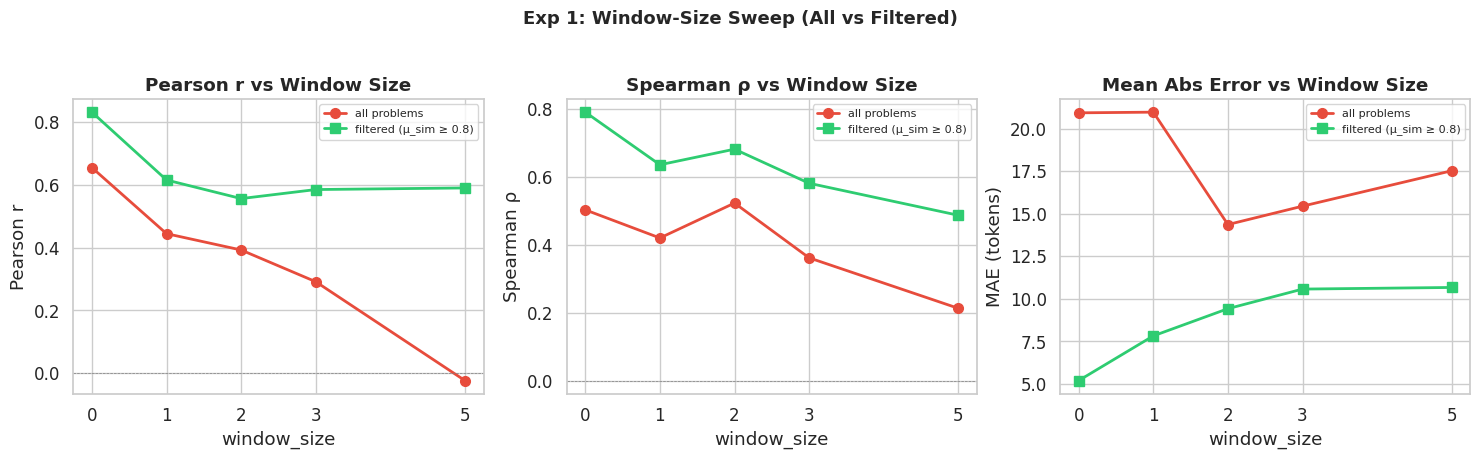


Per-problem table (ws = 0):
   PID   det  true   err     T    μ_sim  sim@true    status
  ──────────────────────────────────────────────────────────
  P 1    26    46    20   112    0.481     0.664   (excl)
  P 2    88    72    16   110    0.940     1.000    ✓
  P 3    45    69    24    94    0.579     0.347   (excl)
  P 4    44    43     1    57    0.994     1.000    ✓
  P 5    51    51     0    81    0.991     1.000    ✓
  P 6   104   103     1   117    0.998     1.000    ✓
  P 7    56    57     1   106    0.984     1.000    ✓
  P 8    60    59     1    74    0.996     1.000    ✓
  P 9    89    62    27   107    0.679     0.422   (excl)
  P10    67    59     8    81    0.998     1.000    ✓
  P11     6    31    25    73    0.389     0.636   (excl)
  P12     1    36    35    77    0.348     0.396   (excl)
  P13    34    34     0    51    0.990     1.000    ✓
  P14    78    67    11   109    0.491     0.345   (excl)
  P15    68    58    10    75    0.997     1.000    ✓
  P16    69    6

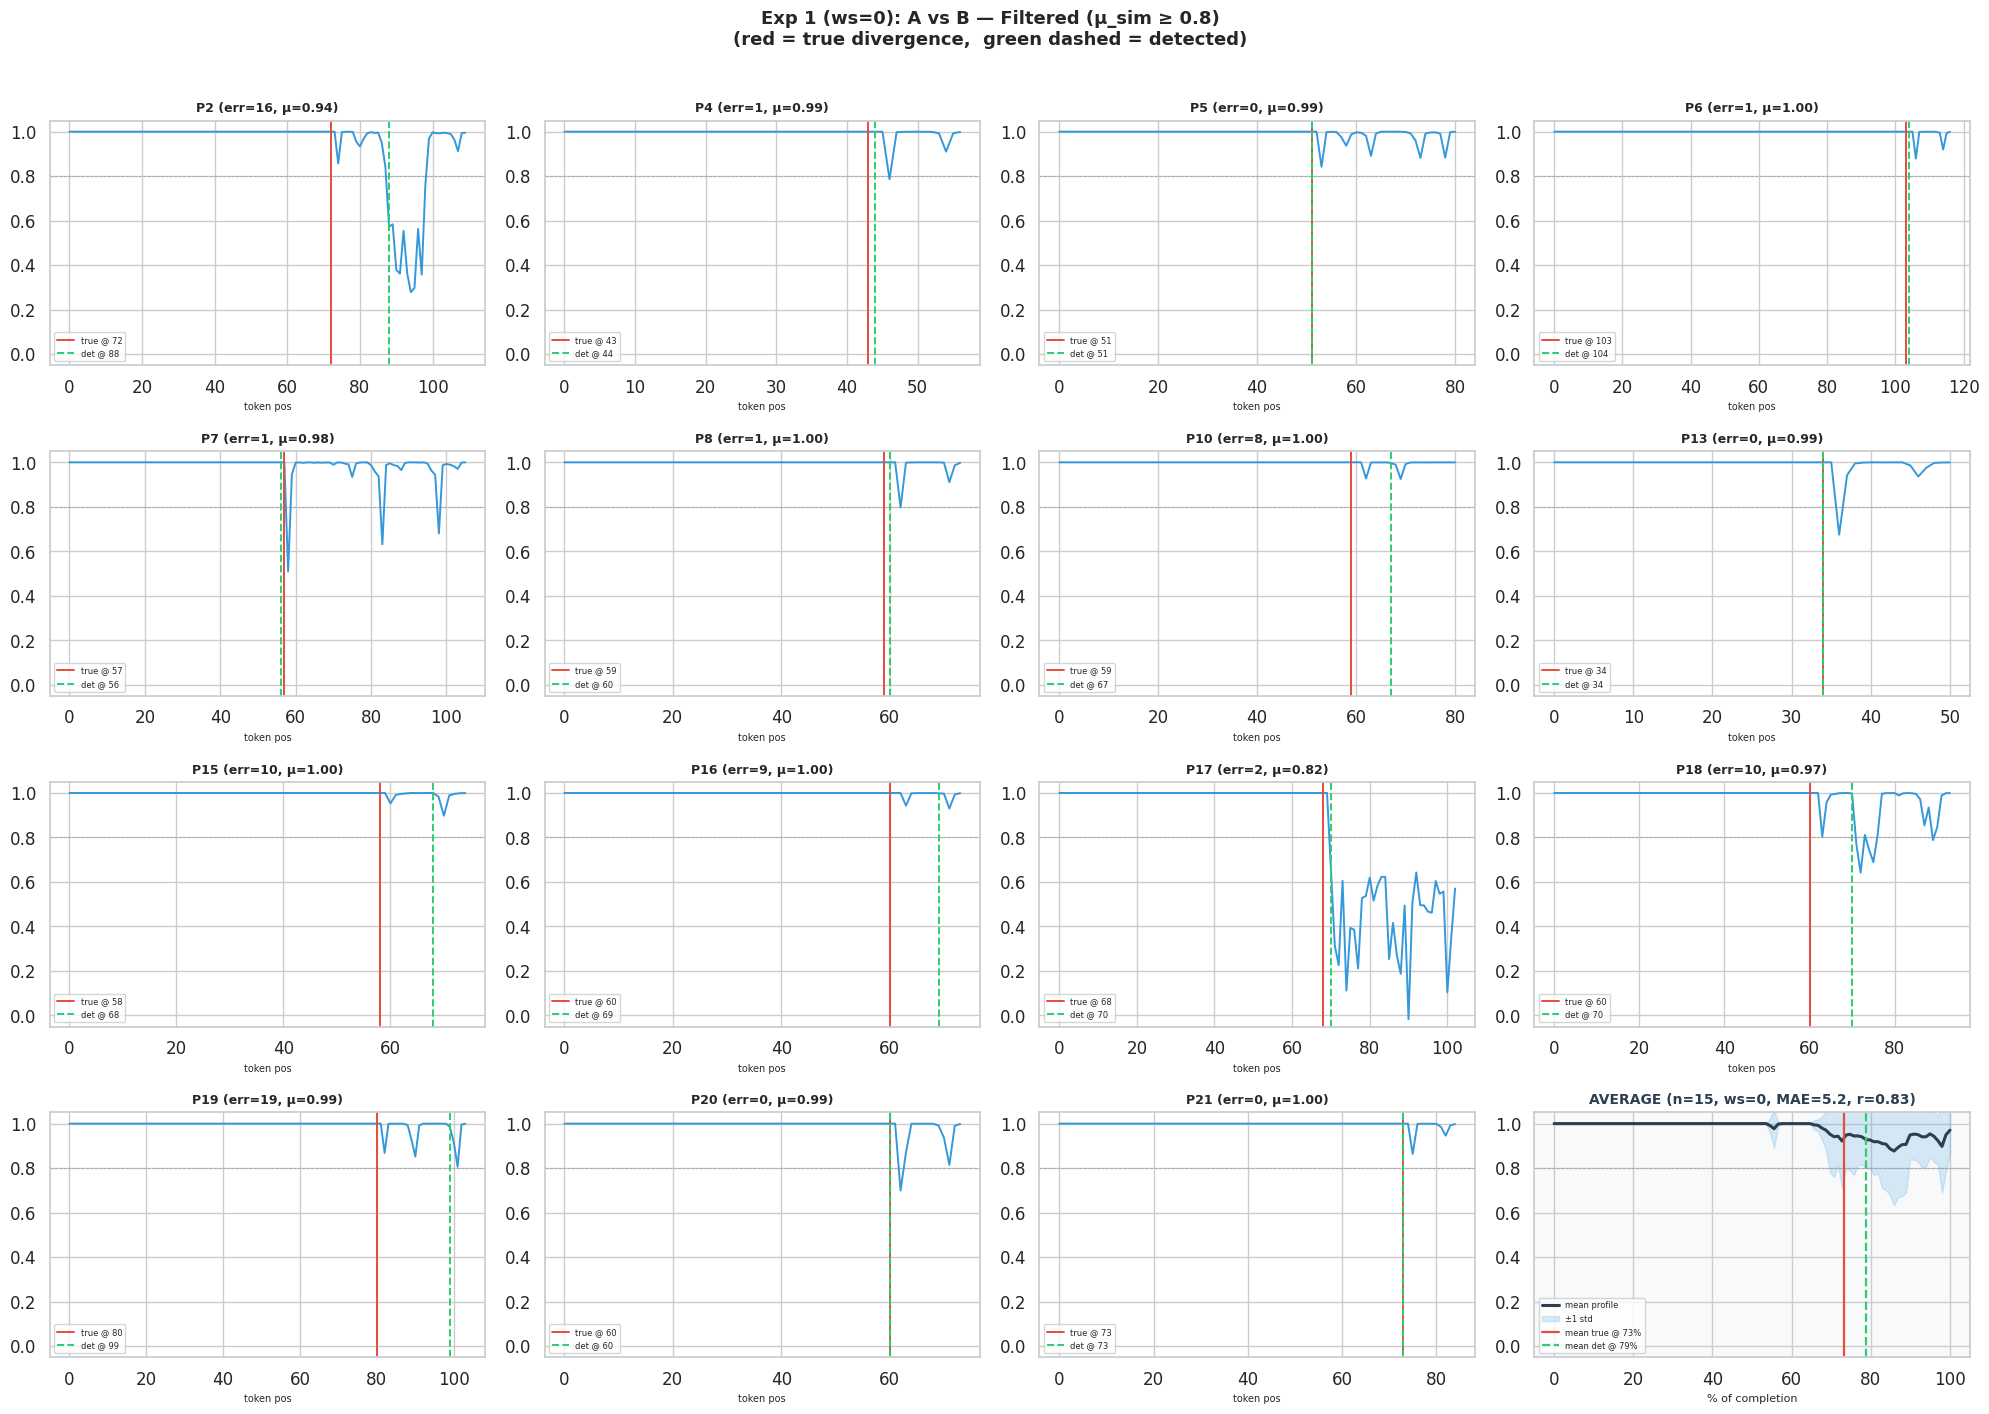

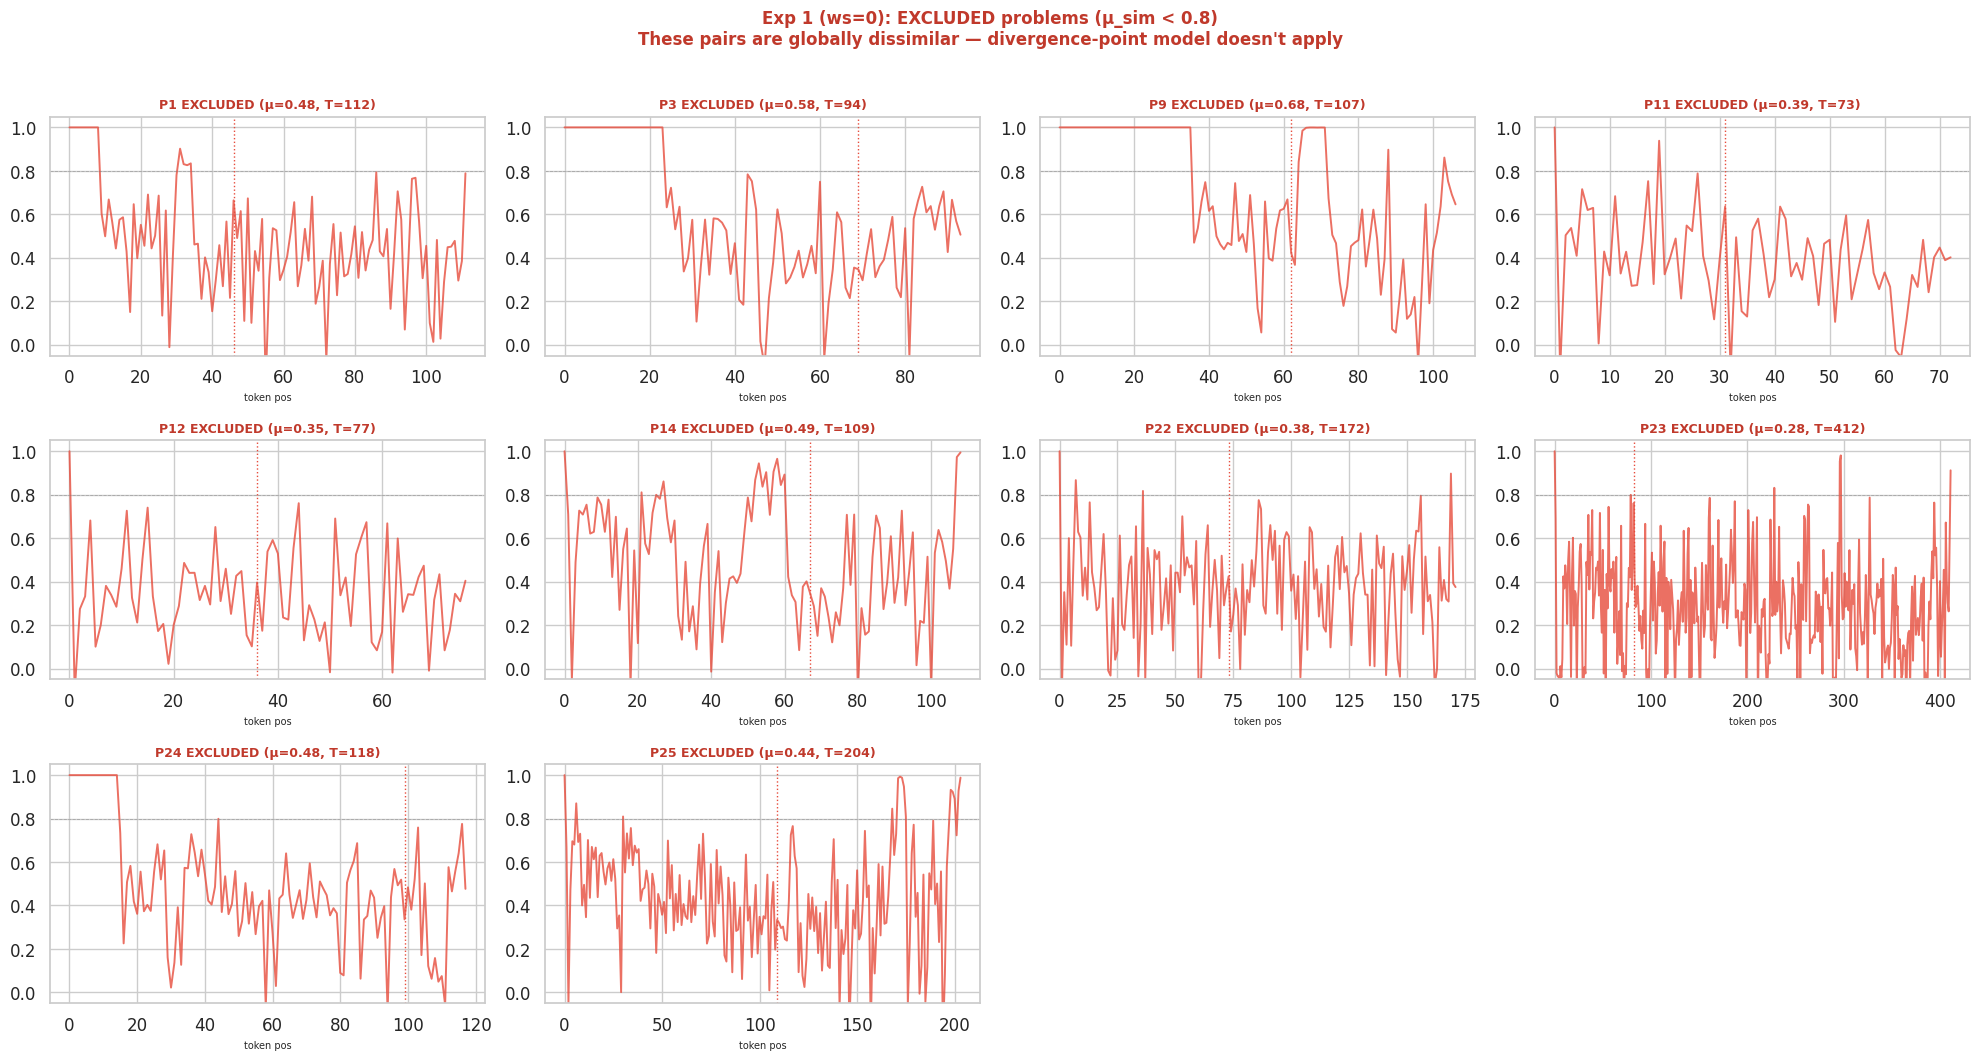

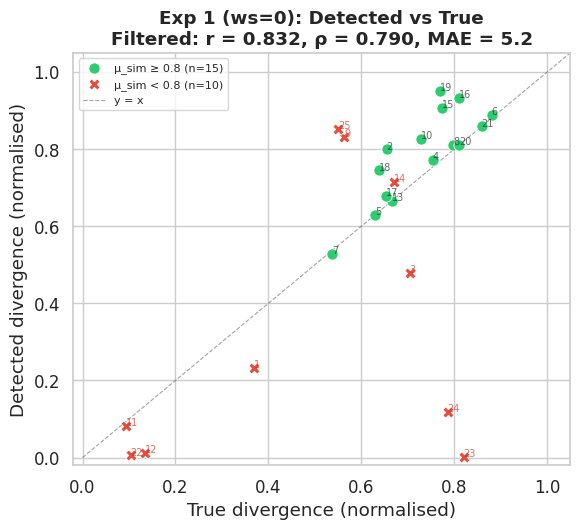


✅ All Experiment 1 plots saved to denser_results/


In [8]:
# ═══════════════════════════════════════════════════════════════════════
# Experiment 1 — Divergence-Point Recovery (with window sweep & filtering)
# ═══════════════════════════════════════════════════════════════════════

layer = LAST_LAYER
WINDOW_SIZES = [0, 1, 2, 3, 5]
MEAN_SIM_THRESHOLD = 0.8          # filter out "globally different" pairs
N_BINS = 100                      # for resampled average profile

# ── Helper: run exp1 for a given window size ────────────────────────
def run_exp1_for_window(ws):
    records = []
    for prob in problems:
        pid = prob["id"]
        enc = encoded.get(pid, {})
        if "A" not in enc or "B" not in enc:
            continue

        sim = windowed_cosine_similarity(
            enc["A"]["states"][layer],
            enc["B"]["states"][layer],
            ws=ws)

        det  = detect_divergence_point(sim)
        true = true_divergence_index(prob["completions"]["B"])
        if true is None:
            continue

        T = len(sim)
        mean_sim = float(np.mean(sim))
        sim_at_true = float(sim[min(true, T - 1)])

        records.append(dict(
            pid=pid, det=det, true=true, err=abs(det - true), T=T,
            det_norm=det / T,
            true_norm=true / max(len(enc["B"]["tokens"]), 1),
            mean_sim=mean_sim,
            sim_at_true=sim_at_true,
            profile=sim,
        ))
    return records


def compute_stats(records):
    """Pearson r, Spearman ρ, MAE from a list of exp1 records."""
    if len(records) < 3:
        return float("nan"), float("nan"), float("nan")
    det_n = [r["det_norm"] for r in records]
    tru_n = [r["true_norm"] for r in records]
    pr = pearsonr(det_n, tru_n)[0]
    sr = spearmanr(det_n, tru_n)[0]
    mae = np.mean([r["err"] for r in records])
    return pr, sr, mae


# ── Sweep over window sizes ─────────────────────────────────────────
sweep_results = {}    # ws -> {"all": records, "filtered": records, ...}

print(f"{'ws':>3s}  │  {'n_all':>5s}  {'r_all':>7s}  {'ρ_all':>7s}  {'MAE_all':>7s}"
      f"  │  {'n_flt':>5s}  {'r_flt':>7s}  {'ρ_flt':>7s}  {'MAE_flt':>7s}"
      f"  │  {'mean sim@true':>13s}")
print("─" * 100)

for ws in WINDOW_SIZES:
    recs = run_exp1_for_window(ws)
    filt = [r for r in recs if r["mean_sim"] >= MEAN_SIM_THRESHOLD]

    pr_a, sr_a, mae_a = compute_stats(recs)
    pr_f, sr_f, mae_f = compute_stats(filt)

    avg_sat = np.mean([r["sim_at_true"] for r in recs]) if recs else float("nan")

    sweep_results[ws] = dict(
        all=recs, filtered=filt,
        pr_a=pr_a, sr_a=sr_a, mae_a=mae_a,
        pr_f=pr_f, sr_f=sr_f, mae_f=mae_f,
        avg_sat=avg_sat,
    )

    print(f"{ws:>3d}  │  {len(recs):>5d}  {pr_a:>7.3f}  {sr_a:>7.3f}  {mae_a:>7.1f}"
          f"  │  {len(filt):>5d}  {pr_f:>7.3f}  {sr_f:>7.3f}  {mae_f:>7.1f}"
          f"  │  {avg_sat:>13.3f}")

# ── Pick best window by filtered Pearson r ──────────────────────────
best_ws = max(WINDOW_SIZES, key=lambda w: sweep_results[w]["pr_f"]
              if not np.isnan(sweep_results[w]["pr_f"]) else -999)
print(f"\n★ Best window (by filtered Pearson r): ws = {best_ws}")


# ═══════════════════════════════════════════════════════════════════════
# Plot 1: Window-size sweep summary
# ═══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# — Pearson r —
ax = axes[0]
ax.plot(WINDOW_SIZES, [sweep_results[w]["pr_a"] for w in WINDOW_SIZES],
        "o-", color="#e74c3c", lw=2, ms=7, label="all problems")
ax.plot(WINDOW_SIZES, [sweep_results[w]["pr_f"] for w in WINDOW_SIZES],
        "s-", color="#2ecc71", lw=2, ms=7, label=f"filtered (μ_sim ≥ {MEAN_SIM_THRESHOLD})")
ax.set_xlabel("window_size")
ax.set_ylabel("Pearson r")
ax.set_title("Pearson r vs Window Size", fontweight="bold")
ax.set_xticks(WINDOW_SIZES)
ax.legend(fontsize=8)
ax.axhline(0, color="grey", lw=0.5, ls="--")

# — Spearman ρ —
ax = axes[1]
ax.plot(WINDOW_SIZES, [sweep_results[w]["sr_a"] for w in WINDOW_SIZES],
        "o-", color="#e74c3c", lw=2, ms=7, label="all problems")
ax.plot(WINDOW_SIZES, [sweep_results[w]["sr_f"] for w in WINDOW_SIZES],
        "s-", color="#2ecc71", lw=2, ms=7, label=f"filtered (μ_sim ≥ {MEAN_SIM_THRESHOLD})")
ax.set_xlabel("window_size")
ax.set_ylabel("Spearman ρ")
ax.set_title("Spearman ρ vs Window Size", fontweight="bold")
ax.set_xticks(WINDOW_SIZES)
ax.legend(fontsize=8)
ax.axhline(0, color="grey", lw=0.5, ls="--")

# — MAE —
ax = axes[2]
ax.plot(WINDOW_SIZES, [sweep_results[w]["mae_a"] for w in WINDOW_SIZES],
        "o-", color="#e74c3c", lw=2, ms=7, label="all problems")
ax.plot(WINDOW_SIZES, [sweep_results[w]["mae_f"] for w in WINDOW_SIZES],
        "s-", color="#2ecc71", lw=2, ms=7, label=f"filtered (μ_sim ≥ {MEAN_SIM_THRESHOLD})")
ax.set_xlabel("window_size")
ax.set_ylabel("MAE (tokens)")
ax.set_title("Mean Abs Error vs Window Size", fontweight="bold")
ax.set_xticks(WINDOW_SIZES)
ax.legend(fontsize=8)

fig.suptitle("Exp 1: Window-Size Sweep (All vs Filtered)",
             fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp1_window_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 2: Per-problem profiles at BEST window, split into two groups
# ═══════════════════════════════════════════════════════════════════════

best = sweep_results[best_ws]
recs_all = best["all"]
recs_filt = best["filtered"]
recs_excl = [r for r in recs_all if r["mean_sim"] < MEAN_SIM_THRESHOLD]

# ── Detailed per-problem table ──────────────────────────────────────
print(f"\nPer-problem table (ws = {best_ws}):")
print(f"  {'PID':>4s}  {'det':>4s}  {'true':>4s}  {'err':>4s}  {'T':>4s}"
      f"  {'μ_sim':>7s}  {'sim@true':>8s}  {'status':>8s}")
print(f"  {'─'*58}")

for r in recs_all:
    status = "  ✓" if r["mean_sim"] >= MEAN_SIM_THRESHOLD else " (excl)"
    print(f"  P{r['pid']:>2d}  {r['det']:>4d}  {r['true']:>4d}  {r['err']:>4d}  {r['T']:>4d}"
          f"  {r['mean_sim']:>7.3f}  {r['sim_at_true']:>8.3f}  {status}")

pr_f, sr_f, mae_f = compute_stats(recs_filt)
avg_msim_f = np.mean([r["mean_sim"] for r in recs_filt]) if recs_filt else 0
avg_sat_f  = np.mean([r["sim_at_true"] for r in recs_filt]) if recs_filt else 0
print(f"  {'─'*58}")
print(f"  FILT (n={len(recs_filt):>2d}) {' ':>9s}  {mae_f:>4.1f}  {' ':>4s}"
      f"  {avg_msim_f:>7.3f}  {avg_sat_f:>8.3f}")
print(f"  Pearson r = {pr_f:.4f},  Spearman ρ = {sr_f:.4f}")

# ── Grid: filtered problems + average ───────────────────────────────
n_f = len(recs_filt)
cols = 4
total_panels = n_f + 1   # +1 for average
rows = (total_panels + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.5*rows), squeeze=False)

for idx, rec in enumerate(recs_filt):
    ax = axes[idx // cols][idx % cols]
    T = len(rec["profile"])
    ax.plot(rec["profile"], color="#3498db", lw=1.4)
    ax.axhline(0.8, color="grey", ls="--", lw=0.6, alpha=0.5)
    if rec["true"] < T:
        ax.axvline(rec["true"], color="#e74c3c", lw=1.4,
                   label=f'true @ {rec["true"]}')
    if rec["det"] < T:
        ax.axvline(rec["det"], color="#2ecc71", ls="--", lw=1.4,
                   label=f'det @ {rec["det"]}')
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'P{rec["pid"]} (err={rec["err"]}, μ={rec["mean_sim"]:.2f})',
                 fontsize=9, fontweight="bold")
    ax.legend(fontsize=6, loc="lower left")
    ax.set_xlabel("token pos", fontsize=7)

# ── Average panel ────────────────────────────────────────────────────
resampled = []
resampled_true_frac = []
resampled_det_frac  = []
for r in recs_filt:
    T = len(r["profile"])
    x_orig = np.linspace(0, 1, T)
    x_new  = np.linspace(0, 1, N_BINS)
    resampled.append(np.interp(x_new, x_orig, r["profile"]))
    resampled_true_frac.append(r["true"] / T)
    resampled_det_frac.append(r["det"] / T)

resampled = np.array(resampled)
avg_profile = resampled.mean(axis=0)
std_profile = resampled.std(axis=0)
avg_true_frac = np.mean(resampled_true_frac)
avg_det_frac  = np.mean(resampled_det_frac)

avg_idx = n_f
ax_avg = axes[avg_idx // cols][avg_idx % cols]
x_pct = np.linspace(0, 100, N_BINS)

ax_avg.plot(x_pct, avg_profile, color="#2c3e50", lw=2.2, label="mean profile")
ax_avg.fill_between(x_pct, avg_profile - std_profile, avg_profile + std_profile,
                    color="#3498db", alpha=0.18, label="±1 std")
ax_avg.axhline(0.8, color="grey", ls="--", lw=0.6, alpha=0.5)
ax_avg.axvline(avg_true_frac * 100, color="#e74c3c", lw=1.6,
               label=f"mean true @ {avg_true_frac*100:.0f}%")
ax_avg.axvline(avg_det_frac * 100, color="#2ecc71", ls="--", lw=1.6,
               label=f"mean det @ {avg_det_frac*100:.0f}%")
ax_avg.set_ylim(-0.05, 1.05)
ax_avg.set_xlabel("% of completion", fontsize=8)
ax_avg.set_title(f"AVERAGE (n={n_f}, ws={best_ws}, MAE={mae_f:.1f}, r={pr_f:.2f})",
                 fontsize=10, fontweight="bold", color="#2c3e50")
ax_avg.legend(fontsize=6, loc="lower left")
ax_avg.set_facecolor("#f7f9fb")

for idx in range(avg_idx + 1, rows * cols):
    axes[idx // cols][idx % cols].set_visible(False)

fig.suptitle(f"Exp 1 (ws={best_ws}): A vs B — Filtered (μ_sim ≥ {MEAN_SIM_THRESHOLD})\n"
             f"(red = true divergence,  green dashed = detected)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp1_AB_profiles_filtered_ws{best_ws}.png",
            dpi=180, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 3: Excluded problems (mean_sim < threshold) — for diagnosis
# ═══════════════════════════════════════════════════════════════════════

if recs_excl:
    n_e = len(recs_excl)
    cols_e = min(4, n_e)
    rows_e = (n_e + cols_e - 1) // cols_e

    fig, axes = plt.subplots(rows_e, cols_e, figsize=(5*cols_e, 3.5*rows_e),
                              squeeze=False)
    for idx, rec in enumerate(recs_excl):
        ax = axes[idx // cols_e][idx % cols_e]
        T = len(rec["profile"])
        ax.plot(rec["profile"], color="#e74c3c", lw=1.4, alpha=0.8)
        ax.axhline(0.8, color="grey", ls="--", lw=0.6, alpha=0.5)
        if rec["true"] < T:
            ax.axvline(rec["true"], color="#e74c3c", lw=1.0, ls=":")
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'P{rec["pid"]} EXCLUDED (μ={rec["mean_sim"]:.2f}, T={rec["T"]})',
                     fontsize=9, fontweight="bold", color="#c0392b")
        ax.set_xlabel("token pos", fontsize=7)

    for idx in range(n_e, rows_e * cols_e):
        axes[idx // cols_e][idx % cols_e].set_visible(False)

    fig.suptitle(f"Exp 1 (ws={best_ws}): EXCLUDED problems (μ_sim < {MEAN_SIM_THRESHOLD})\n"
                 "These pairs are globally dissimilar — divergence-point model doesn't apply",
                 fontsize=12, fontweight="bold", color="#c0392b", y=1.01)
    fig.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/exp1_AB_excluded_ws{best_ws}.png",
                dpi=180, bbox_inches="tight")
    plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 4: Scatter — detected vs true (best window, both groups)
# ═══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(6, 5.5))

# Filtered (green)
if recs_filt:
    det_f = [r["det_norm"] for r in recs_filt]
    tru_f = [r["true_norm"] for r in recs_filt]
    ax.scatter(tru_f, det_f, s=65, c="#2ecc71", edgecolors="white", lw=0.6,
              zorder=3, label=f"μ_sim ≥ {MEAN_SIM_THRESHOLD} (n={len(recs_filt)})")
    for r in recs_filt:
        ax.annotate(str(r["pid"]), (r["true_norm"], r["det_norm"]),
                    fontsize=7, alpha=0.7)

# Excluded (red, X marker)
if recs_excl:
    det_e = [r["det_norm"] for r in recs_excl]
    tru_e = [r["true_norm"] for r in recs_excl]
    ax.scatter(tru_e, det_e, s=65, c="#e74c3c", marker="X", edgecolors="white",
              lw=0.6, zorder=3, label=f"μ_sim < {MEAN_SIM_THRESHOLD} (n={len(recs_excl)})")
    for r in recs_excl:
        ax.annotate(str(r["pid"]), (r["true_norm"], r["det_norm"]),
                    fontsize=7, alpha=0.7, color="#c0392b")

hi = 1.05
ax.plot([0, hi], [0, hi], "k--", lw=0.8, alpha=0.4, label="y = x")
ax.set_xlim(-0.02, hi)
ax.set_ylim(-0.02, hi)
ax.set_xlabel("True divergence (normalised)")
ax.set_ylabel("Detected divergence (normalised)")
ax.set_title(f"Exp 1 (ws={best_ws}): Detected vs True\n"
             f"Filtered: r = {pr_f:.3f}, ρ = {sr_f:.3f}, MAE = {mae_f:.1f}",
             fontweight="bold")
ax.legend(fontsize=8, loc="upper left")

fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp1_scatter_ws{best_ws}.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\n✅ All Experiment 1 plots saved to {OUTPUT_DIR}/")

---
## 6 · Experiment 2 — Divergence Magnitude vs Semantic Distance

 ws  │    A vs A_para         A vs B         A vs C         A vs D         B vs D  │  ordering?
───────────────────────────────────────────────────────────────────────────────────────────────
  0  │         0.5534         0.2316         0.5572         0.5733         0.5731  │  ✗ (2/3)
  1  │         0.3811         0.1451         0.3999         0.4136         0.4128  │  ✗ (2/3)
  2  │         0.3049         0.1121         0.3329         0.3408         0.3444  │  ✗ (2/3)
  3  │         0.2576         0.0903         0.2932         0.3002         0.3044  │  ✗ (2/3)
  5  │         0.2051         0.0696         0.2457         0.2428         0.2493  │  ✗ (1/3)

 ws  │  gap(B-para)    gap(CD-B)  │  interpretation
──────────────────────────────────────────────────────────────────────
  0  │      -0.3218       0.3336  │  weak separation
  1  │      -0.2360       0.2616  │  weak separation
  2  │      -0.1927       0.2247  │  weak separation
  3  │      -0.1673       0.2064  │  weak separation
  

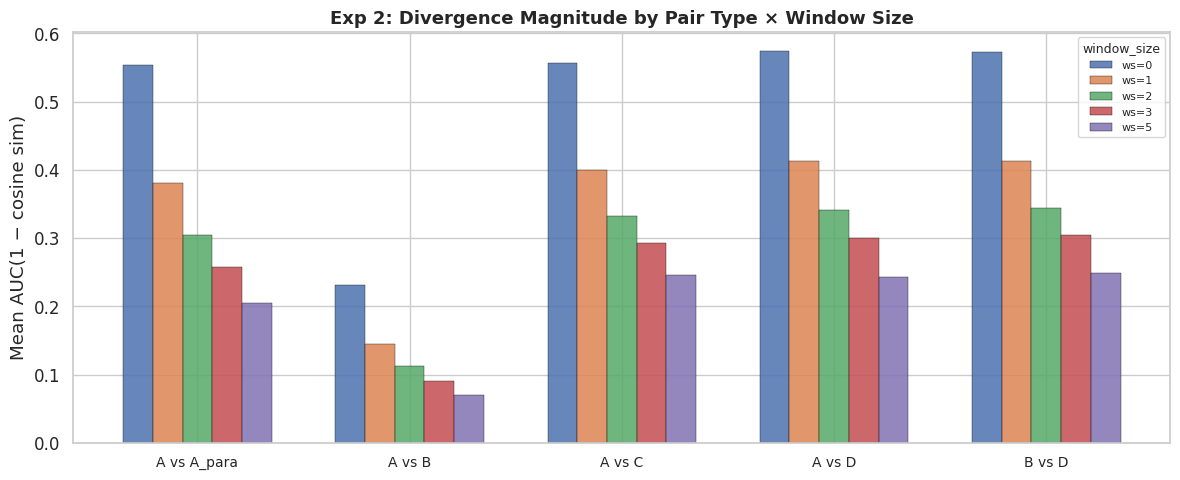

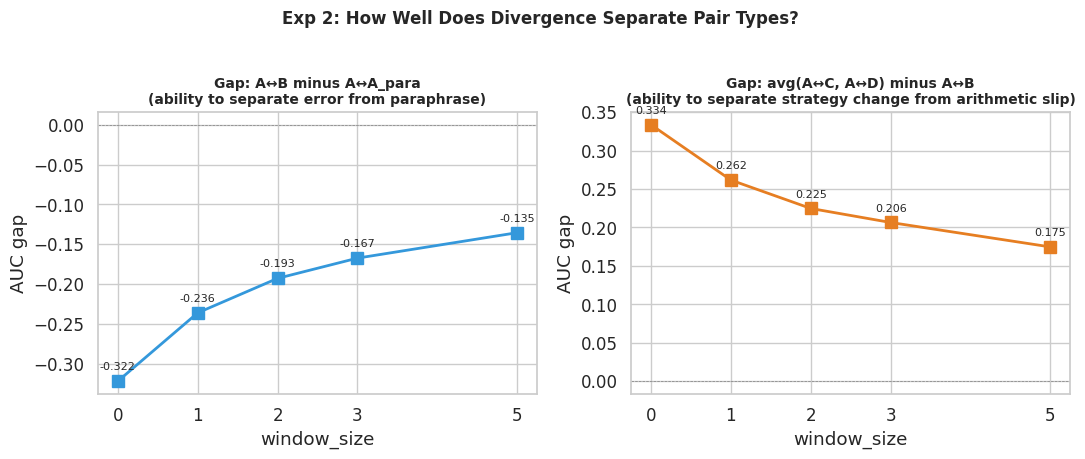

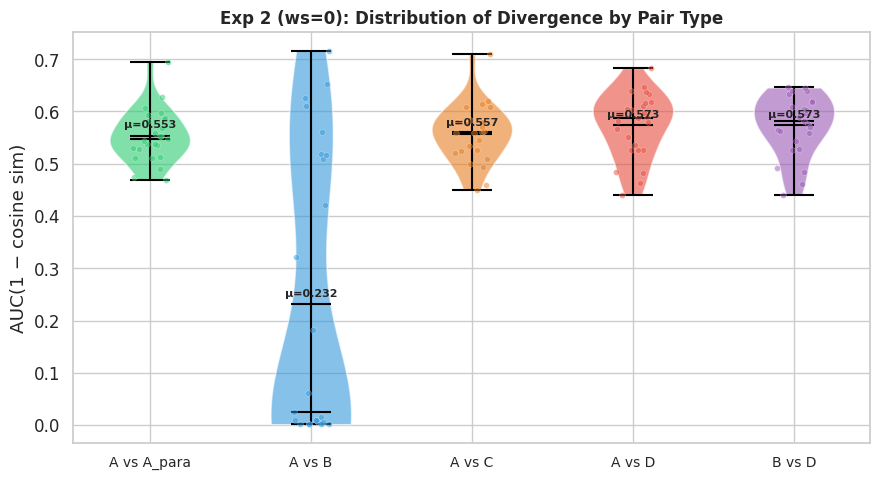

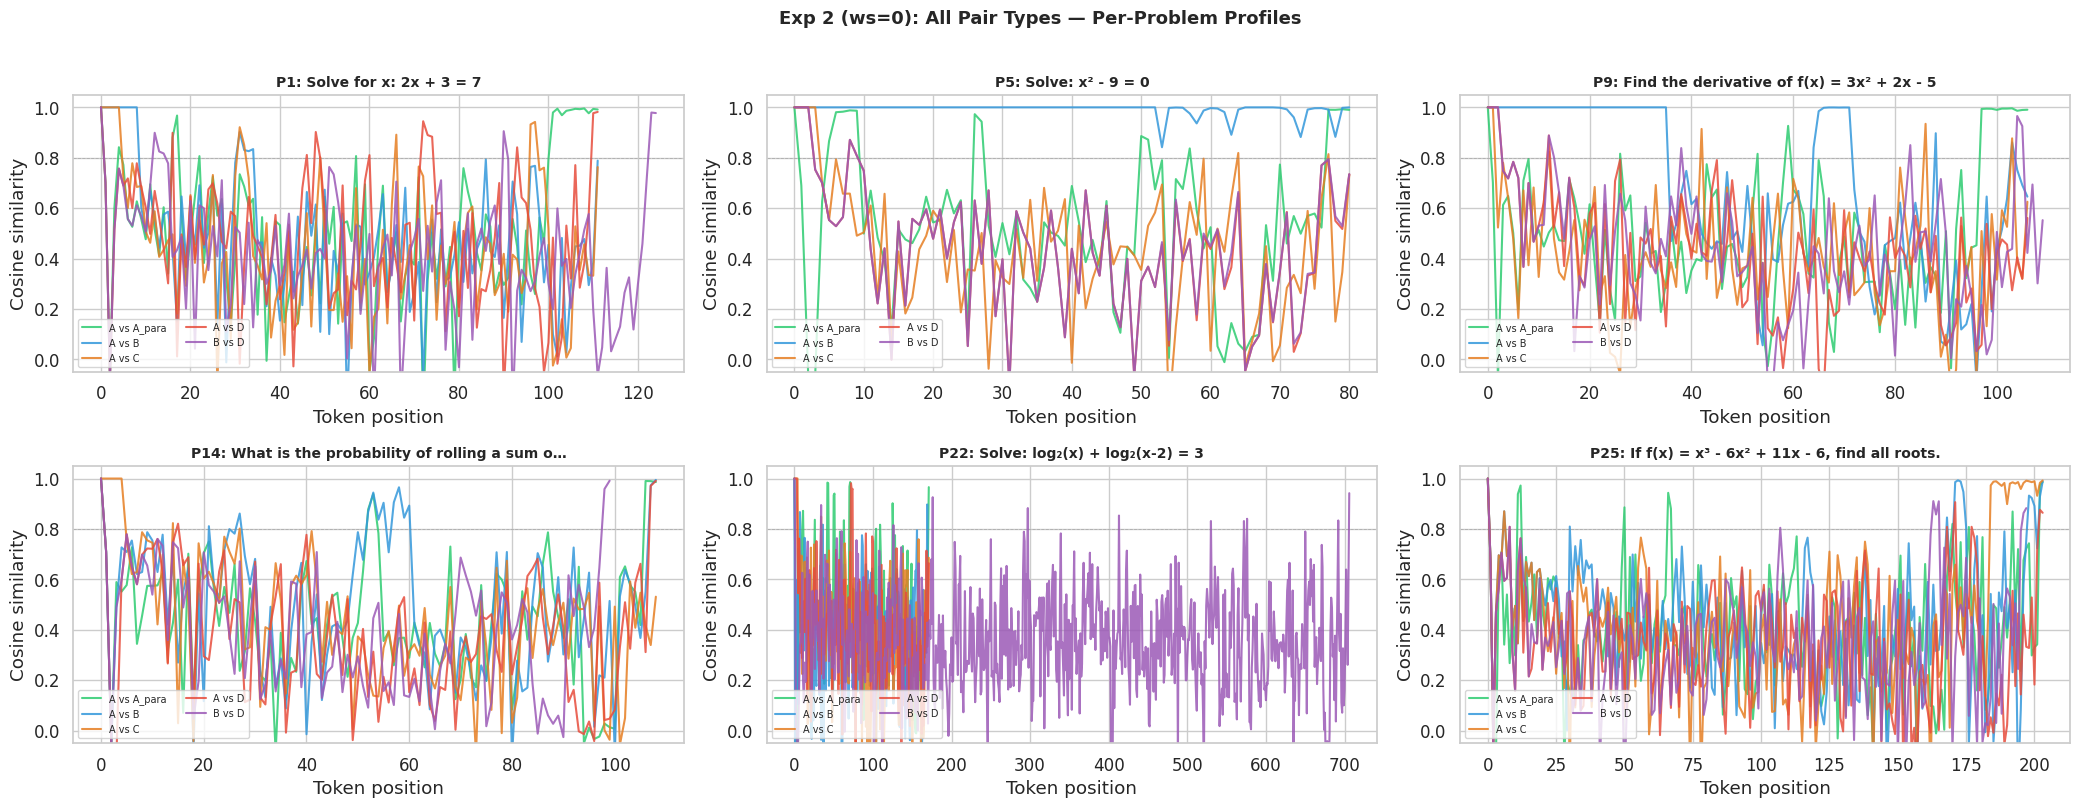

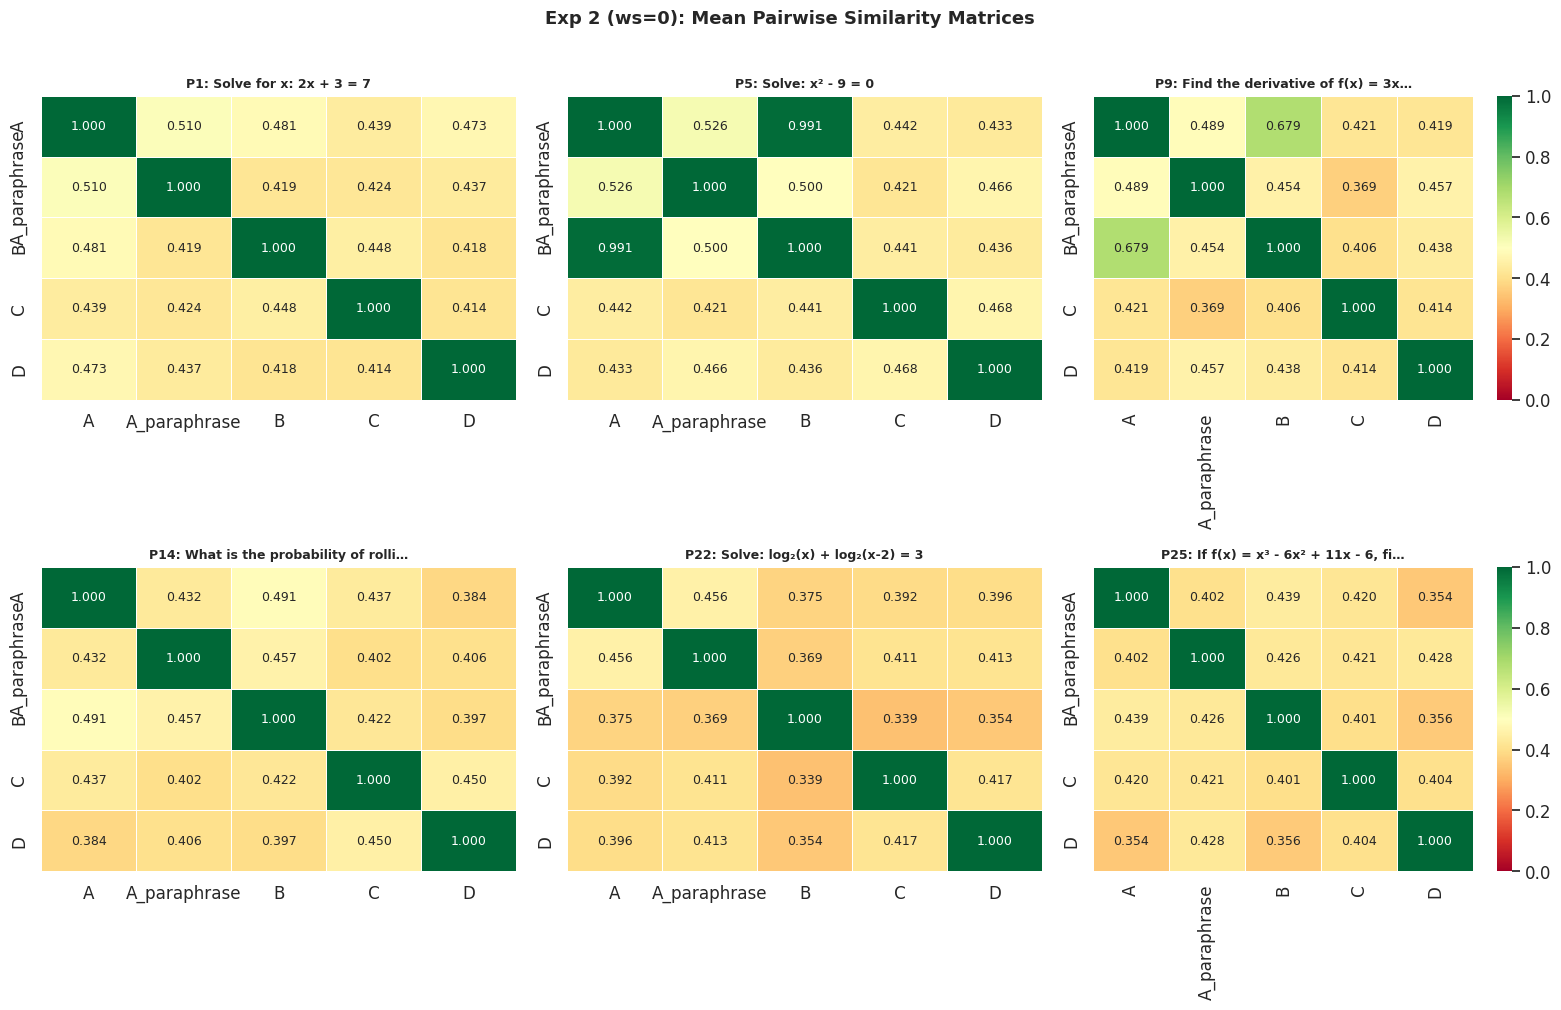


✅ All Experiment 2 plots saved to denser_results/


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Experiment 2 — Divergence Magnitude vs Semantic Distance
#                (with window sweep & detailed analysis)
# ═══════════════════════════════════════════════════════════════════════

layer = LAST_LAYER
WINDOW_SIZES = [0, 1, 2, 3, 5]

PAIR_SPEC = [
    ("A", "A_paraphrase", "A vs A_para"),
    ("A", "B",            "A vs B"),
    ("A", "C",            "A vs C"),
    ("A", "D",            "A vs D"),
    ("B", "D",            "B vs D"),
]
# Expected ordering for the first 4 (B vs D is supplementary)
ORDERED_LABELS = ["A vs A_para", "A vs B", "A vs C", "A vs D"]

PAIR_COLORS = {
    "A vs A_para": "#2ecc71",
    "A vs B":      "#3498db",
    "A vs C":      "#e67e22",
    "A vs D":      "#e74c3c",
    "B vs D":      "#9b59b6",
}


# ── Helper: run exp2 for a given window size ────────────────────────
def run_exp2_for_window(ws):
    buckets = defaultdict(list)
    for prob in problems:
        pid = prob["id"]
        enc = encoded.get(pid, {})
        for t1, t2, label in PAIR_SPEC:
            if t1 not in enc or t2 not in enc:
                continue
            sim = windowed_cosine_similarity(
                enc[t1]["states"][layer],
                enc[t2]["states"][layer], ws=ws)
            buckets[label].append(dict(pid=pid, auc=float(np.mean(1 - sim)),
                                       profile=sim))
    means = {}
    for label in [p[2] for p in PAIR_SPEC]:
        vals = [r["auc"] for r in buckets[label]]
        if vals:
            means[label] = np.mean(vals)
    return buckets, means


# ── Sweep over window sizes ─────────────────────────────────────────
sweep2 = {}

print(f"{'ws':>3s}  │  ", end="")
for label in ORDERED_LABELS + ["B vs D"]:
    print(f"{label:>13s}", end="  ")
print("│  ordering?")
print("─" * 95)

for ws in WINDOW_SIZES:
    buckets, means = run_exp2_for_window(ws)

    # Check pairwise ordering for the 4 expected labels
    available = [l for l in ORDERED_LABELS if l in means]
    pairwise_ok = sum(means[available[i]] <= means[available[i+1]]
                      for i in range(len(available) - 1))
    total_pairs = len(available) - 1
    ordering_ok = pairwise_ok == total_pairs

    # Separation: gap between smallest cross-class (A vs B) and paraphrase
    gap_ab_para = means.get("A vs B", 0) - means.get("A vs A_para", 0)
    # Gap between A vs C/D and A vs B
    gap_cd_b = (np.mean([means.get("A vs C", 0), means.get("A vs D", 0)])
                - means.get("A vs B", 0))

    sweep2[ws] = dict(buckets=buckets, means=means,
                      ordering_ok=ordering_ok, pairwise_ok=pairwise_ok,
                      gap_ab_para=gap_ab_para, gap_cd_b=gap_cd_b)

    print(f"{ws:>3d}  │  ", end="")
    for label in ORDERED_LABELS + ["B vs D"]:
        v = means.get(label, float("nan"))
        print(f"{v:>13.4f}", end="  ")
    check = "✓" if ordering_ok else f"✗ ({pairwise_ok}/{total_pairs})"
    print(f"│  {check}")

print()
print(f"{'ws':>3s}  │  {'gap(B-para)':>11s}  {'gap(CD-B)':>11s}  │  interpretation")
print("─" * 70)
for ws in WINDOW_SIZES:
    s = sweep2[ws]
    interp = ("sharp separation" if s["gap_ab_para"] > 0.05 and s["gap_cd_b"] > 0.05
              else "moderate" if s["gap_ab_para"] > 0.02
              else "weak separation")
    print(f"{ws:>3d}  │  {s['gap_ab_para']:>11.4f}  {s['gap_cd_b']:>11.4f}  │  {interp}")


# ═══════════════════════════════════════════════════════════════════════
# Plot 1: Mean AUC by pair type — one group of bars per window size
# ═══════════════════════════════════════════════════════════════════════

all_labels = [p[2] for p in PAIR_SPEC]
n_labels = len(all_labels)
n_ws = len(WINDOW_SIZES)
bar_width = 0.14
x_base = np.arange(n_labels)

fig, ax = plt.subplots(figsize=(12, 5))

for i, ws in enumerate(WINDOW_SIZES):
    means = sweep2[ws]["means"]
    vals = [means.get(l, 0) for l in all_labels]
    offset = (i - n_ws / 2 + 0.5) * bar_width
    bars = ax.bar(x_base + offset, vals, width=bar_width,
                  label=f"ws={ws}", alpha=0.85, edgecolor="black", lw=0.3)

ax.set_xticks(x_base)
ax.set_xticklabels(all_labels, fontsize=10)
ax.set_ylabel("Mean AUC(1 − cosine sim)")
ax.set_title("Exp 2: Divergence Magnitude by Pair Type × Window Size",
             fontsize=13, fontweight="bold")
ax.legend(title="window_size", fontsize=8, title_fontsize=9)
ax.set_ylim(0)

fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp2_bars_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 2: Separation gaps as a function of window size
# ═══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

gap_ab = [sweep2[ws]["gap_ab_para"] for ws in WINDOW_SIZES]
gap_cd = [sweep2[ws]["gap_cd_b"] for ws in WINDOW_SIZES]

ax = axes[0]
ax.plot(WINDOW_SIZES, gap_ab, "s-", color="#3498db", lw=2, ms=8)
for i, (ws, g) in enumerate(zip(WINDOW_SIZES, gap_ab)):
    ax.annotate(f"{g:.3f}", (ws, g), textcoords="offset points",
                xytext=(0, 8), fontsize=8, ha="center")
ax.set_xlabel("window_size")
ax.set_ylabel("AUC gap")
ax.set_title("Gap: A↔B minus A↔A_para\n(ability to separate error from paraphrase)",
             fontweight="bold", fontsize=10)
ax.set_xticks(WINDOW_SIZES)
ax.axhline(0, color="grey", lw=0.5, ls="--")

ax = axes[1]
ax.plot(WINDOW_SIZES, gap_cd, "s-", color="#e67e22", lw=2, ms=8)
for i, (ws, g) in enumerate(zip(WINDOW_SIZES, gap_cd)):
    ax.annotate(f"{g:.3f}", (ws, g), textcoords="offset points",
                xytext=(0, 8), fontsize=8, ha="center")
ax.set_xlabel("window_size")
ax.set_ylabel("AUC gap")
ax.set_title("Gap: avg(A↔C, A↔D) minus A↔B\n(ability to separate strategy change from arithmetic slip)",
             fontweight="bold", fontsize=10)
ax.set_xticks(WINDOW_SIZES)
ax.axhline(0, color="grey", lw=0.5, ls="--")

fig.suptitle("Exp 2: How Well Does Divergence Separate Pair Types?",
             fontsize=12, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp2_gaps_sweep.png", dpi=180, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 3: Violin/box at ws=0 (sharpest separation)
# ═══════════════════════════════════════════════════════════════════════

ws_detail = 0
buckets_detail = sweep2[ws_detail]["buckets"]
means_detail   = sweep2[ws_detail]["means"]
labels_detail  = [l for l in all_labels if l in buckets_detail and buckets_detail[l]]
data_lists     = [[r["auc"] for r in buckets_detail[l]] for l in labels_detail]
colors_detail  = [PAIR_COLORS[l] for l in labels_detail]

fig, ax = plt.subplots(figsize=(9, 5))
parts = ax.violinplot(data_lists, positions=range(len(labels_detail)),
                      showmeans=True, showmedians=True)
for i, pc in enumerate(parts["bodies"]):
    pc.set_facecolor(colors_detail[i])
    pc.set_alpha(0.6)
for k in ("cmeans", "cmedians", "cbars", "cmins", "cmaxes"):
    if k in parts:
        parts[k].set_color("black")

# Overlay individual points
for i, (vals, label) in enumerate(zip(data_lists, labels_detail)):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, s=18,
              c=colors_detail[i], alpha=0.5, edgecolors="white", lw=0.3, zorder=3)
    ax.text(i, np.mean(vals) + 0.015, f"μ={np.mean(vals):.3f}",
            ha="center", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(labels_detail)))
ax.set_xticklabels(labels_detail, fontsize=10)
ax.set_ylabel("AUC(1 − cosine sim)")
ax.set_title(f"Exp 2 (ws={ws_detail}): Distribution of Divergence by Pair Type",
             fontsize=12, fontweight="bold")

fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp2_violins_ws{ws_detail}.png", dpi=180, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 4: Per-problem overlay at ws=0 for representative problems
# ═══════════════════════════════════════════════════════════════════════

prob_map = {p["id"]: p for p in problems}
DETAIL_PIDS = [1, 5, 9, 14, 22, 25]

n_det = len(DETAIL_PIDS)
cols_d = min(3, n_det)
rows_d = (n_det + cols_d - 1) // cols_d

fig, axes = plt.subplots(rows_d, cols_d, figsize=(7 * cols_d, 4 * rows_d),
                          squeeze=False)

for idx, pid in enumerate(DETAIL_PIDS):
    ax = axes[idx // cols_d][idx % cols_d]
    prob = prob_map.get(pid)
    enc = encoded.get(pid, {})
    if prob is None or not enc:
        ax.set_visible(False)
        continue

    for t1, t2, label in PAIR_SPEC:
        if t1 not in enc or t2 not in enc:
            continue
        sim = windowed_cosine_similarity(
            enc[t1]["states"][layer], enc[t2]["states"][layer], ws=ws_detail)
        ax.plot(sim, label=label, color=PAIR_COLORS[label], lw=1.5, alpha=0.85)

    ax.axhline(0.8, color="grey", ls="--", lw=0.6, alpha=0.4)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Token position")
    ax.set_ylabel("Cosine similarity")
    title = prob["problem"]
    if len(title) > 45:
        title = title[:42] + "…"
    ax.set_title(f"P{pid}: {title}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=7, loc="lower left", ncol=2)

for idx in range(n_det, rows_d * cols_d):
    axes[idx // cols_d][idx % cols_d].set_visible(False)

fig.suptitle(f"Exp 2 (ws={ws_detail}): All Pair Types — Per-Problem Profiles",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp2_per_problem_ws{ws_detail}.png",
            dpi=180, bbox_inches="tight")
plt.show()


# ═══════════════════════════════════════════════════════════════════════
# Plot 5: Similarity matrices at ws=0 for representative problems
# ═══════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(16, 10), squeeze=False)

for idx, pid in enumerate(DETAIL_PIDS):
    ax = axes[idx // 3][idx % 3]
    enc = encoded.get(pid, {})
    types = [t for t in ["A", "A_paraphrase", "B", "C", "D"] if t in enc]
    if len(types) < 3:
        ax.set_visible(False)
        continue

    n_t = len(types)
    mat = np.eye(n_t)
    for i in range(n_t):
        for j in range(i + 1, n_t):
            s = float(np.mean(windowed_cosine_similarity(
                enc[types[i]]["states"][layer],
                enc[types[j]]["states"][layer], ws=ws_detail)))
            mat[i, j] = mat[j, i] = s

    sns.heatmap(mat, annot=True, fmt=".3f", xticklabels=types,
                yticklabels=types, cmap="RdYlGn", vmin=0, vmax=1,
                linewidths=0.5, ax=ax, cbar=idx % 3 == 2,
                annot_kws={"fontsize": 9})
    title = prob_map[pid]["problem"]
    if len(title) > 35:
        title = title[:32] + "…"
    ax.set_title(f"P{pid}: {title}", fontsize=9, fontweight="bold")

for idx in range(len(DETAIL_PIDS), 6):
    axes[idx // 3][idx % 3].set_visible(False)

fig.suptitle(f"Exp 2 (ws={ws_detail}): Mean Pairwise Similarity Matrices",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/exp2_sim_matrices_ws{ws_detail}.png",
            dpi=180, bbox_inches="tight")
plt.show()

print(f"\n✅ All Experiment 2 plots saved to {OUTPUT_DIR}/")